## Download Dataset

In [1]:
!pip install --upgrade gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


In [2]:
import gdown

# 2. Extract your File ID from your public Drive link:
# Format: https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
file_id = "1hEk9EmMmLzURNkpYFDi0uDC7YDYjbDG0"
url = f"https://drive.google.com/uc?id={file_id}"
output_path = "/kaggle/working/data.zip"

# 3. Download the file
gdown.download(url, output_path, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1hEk9EmMmLzURNkpYFDi0uDC7YDYjbDG0
From (redirected): https://drive.google.com/uc?id=1hEk9EmMmLzURNkpYFDi0uDC7YDYjbDG0&confirm=t&uuid=a9771bb3-7276-48f3-b54f-69d0f96011c2
To: /kaggle/working/data.zip
100%|██████████| 1.27G/1.27G [00:08<00:00, 151MB/s]


'/kaggle/working/data.zip'

In [3]:
# -q: quiet (suppresses printing thousands of file paths)
# -o: overwrite existing files without prompting
!unzip -q -o /kaggle/working/data.zip -d /kaggle/working/

# Remove the original zip to free up disk space
!rm /kaggle/working/data.zip

## Download Class Weights

Class weights are pre-computed, with log during generation:
```
Oversampling the following minority classes:
   1 sidewalk       ( 2.044% of pixels)
   3 wall           ( 0.472% of pixels)
   4 fence          ( 1.033% of pixels)
   5 pole           ( 0.936% of pixels)
   6 traffic light  ( 0.185% of pixels)
   7 traffic sign   ( 0.341% of pixels)
   9 terrain        ( 0.999% of pixels)
  11 person         ( 0.267% of pixels)
  12 rider          ( 0.018% of pixels)
  14 truck          ( 0.990% of pixels)
  15 bus            ( 0.550% of pixels)
  16 train          ( 0.013% of pixels)
  17 motorcycle     ( 0.023% of pixels)
  18 bicycle        ( 0.049% of pixels)
```

In [4]:
import gdown

# 2. Extract your File ID from your public Drive link:
# Format: https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
file_id = "1OIFa4WG6fTU9VPXY2iigMNV_c0XQaKeJ"
url = f"https://drive.google.com/uc?id={file_id}"
output_path = "/kaggle/working/data/class_weights.npy"

# 3. Download the file
gdown.download(url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1OIFa4WG6fTU9VPXY2iigMNV_c0XQaKeJ
To: /kaggle/working/data/class_weights.npy
100%|██████████| 44.9k/44.9k [00:00<00:00, 38.0MB/s]


'/kaggle/working/data/class_weights.npy'

## Import

In [5]:
!pip install torchvision albumentations pillow torchinfo matplotlib seaborn graphviz segmentation-models-pytorch jaxtyping beartype tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.2 MB/s eta 0:00:00


In [6]:
import glob
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import torch.optim.lr_scheduler as lr_scheduler

from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchinfo import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

from PIL import Image
from tqdm import tqdm
from typing import Dict, List, cast

from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp

from jaxtyping import Float, UInt8, jaxtyped
from beartype import beartype

## Tensor Declarations

In [7]:
# Shape aliases that document the tensor layout at each stage of the pipeline.
#
# ``h``/``w`` are the spatial dimensions, ``b`` is the batch size and ``c`` is
# the number of channels/classes. These aliases are enforced at runtime by
# ``jaxtyped`` + ``beartype``, so a shape mismatch raises a ``TypeCheckError``
# instead of a confusing downstream broadcast error.
ImageTensor = Float[Tensor, "3 h w"]  # single image, channel-first layout
MaskTensor = Float[Tensor, "c h w"]  # one-hot mask, ``c == NUM_CLASSES``
BatchImage = Float[Tensor, "b 3 h w"]  # collated batch of images
BatchMask = Float[Tensor, "b c h w"]  # collated batch of one-hot masks
Logits = Float[Tensor, "b c h w"]  # model output, ``c == NUM_CLASSES``
ClassMask = Float[Tensor, "c h w"]  # per-sample probability/binary mask, ``c`` channels
Scalar = Float[Tensor, ""]  # scalar (0-dim) tensor
NumpyImage = Float[np.ndarray, "h w 3"]  # single image, channels-last layout
ClassIndexArray = UInt8[np.ndarray, "h w"]  # per-pixel class id map (numpy)

## Class Colors

In [8]:
# BDD100k color-label palette. The row index is the class id (0-19), matching
# ``Configuration.NUM_CLASSES``. Predicted class maps are coloured with this
# same palette so they render side by side with the ground-truth color labels
# stored on disk. The exact colour per class only needs to be distinct and
# consistent; it mirrors the default BDD100k colours.
CLASS_COLORS = np.array([
    [128,  64, 128],   # 0  - Road
    [244,  35, 232],   # 1  - Sidewalk
    [ 70,  70,  70],   # 2  - Building
    [102, 102, 156],   # 3  - Wall
    [190, 153, 153],   # 4  - Fence
    [153, 153, 153],   # 5  - Pole
    [250, 170,  30],   # 6  - Traffic Light
    [220, 220,   0],   # 7  - Traffic Sign
    [107, 142,  35],   # 8  - Vegetation
    [152, 251, 152],   # 9  - Terrain
    [ 70, 130, 180],   # 10 - Sky
    [220,  20,  60],   # 11 - Person
    [255,   0,   0],   # 12 - Rider
    [  0,   0, 142],   # 13 - Car
    [  0,   0,  70],   # 14 - Truck
    [  0,  60, 100],   # 15 - Bus
    [  0,  80, 100],   # 16 - Train
    [  0,   0, 230],   # 17 - Motorcycle
    [119,  11,  32],   # 18 - Bicycle
    [  0,   0,   0],   # 19 - Unknown
], dtype=np.uint8)


# Human-readable names for each palette row, kept in lock-step with
# ``CLASS_COLORS`` so class ids can be logged without consulting the palette
# comments by hand.
CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle",
    "bicycle", "unknown",
]


def color_label_to_class_index(label: np.ndarray) -> np.ndarray:
    """Map an RGB color-label image to a per-pixel class-index map.

    BDD100k stores segmentation masks as RGB PNGs whose colours are exactly
    the entries of ``CLASS_COLORS``. Semantic segmentation needs the class id
    per pixel (shape ``(H, W)``) rather than the RGB representation (shape
    ``(H, W, 3)``), so this conversion must happen before the mask is turned
    into a tensor and one-hot encoded.

    Steps
    -----
    1. Initialise the output with the id of the last palette entry so that any
       unknown colour degrades to ``Unknown`` instead of producing an invalid
       index.
    2. For each palette colour, boolean-mask the pixels whose RGB values match
       it exactly and assign the corresponding class id. The loop is over only
       ``NUM_CLASSES`` colours and each iteration is fully vectorised.

    Parameters
    ----------
    label : np.ndarray
        RGB color-label array of shape ``(H, W, 3)`` with integer values.

    Returns
    -------
    np.ndarray
        Class-index array of shape ``(H, W)`` and dtype ``uint8``, whose values
        are in ``[0, NUM_CLASSES)``.
    """
    # Default to the last class id so unknown colours fall back gracefully
    # instead of indexing the palette out of bounds later.
    class_ids = np.full(label.shape[:2], CLASS_COLORS.shape[0] - 1, dtype=np.uint8)

    # Match each palette colour via exact RGB equality. This stays fast because
    # every comparison operates on the whole image at once.
    for class_id, (red, green, blue) in enumerate(CLASS_COLORS):
        match = (
            (label[..., 0] == red)
            & (label[..., 1] == green)
            & (label[..., 2] == blue)
        )
        class_ids[match] = class_id

    return class_ids

## Configurations

In [9]:
class Configuration:
    DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    NUM_DEVICES = 1
    NUM_WORKERS = 2

    NUM_CLASSES = 20
    EPOCHS = 20
    BATCH_SIZE = 16
    LR = 1e-4
    PATIENCE = 8

    APPLY_SHUFFLE=True
    SEED = 768
    # ``ORIGINAL_IMAGE_HEIGHT``/``ORIGINAL_IMAGE_WIDTH`` describe the spatial extent of a sample.
    # The BDD100k images used here are 720 rows (height) by 1280 columns
    # (width)
    ORIGINAL_IMAGE_HEIGHT = 720
    ORIGINAL_IMAGE_WIDTH = 1280

    # ``IMAGE_HEIGHT``/``IMAGE_WIDTH`` describe the resolution after downscale the images.
    IMAGE_HEIGHT = 360
    IMAGE_WIDTH = 640
    CHANNELS = 3 # RGB


class Path:
    BASE = "/kaggle/working/data/bdd100k"

    SEGMENTATION_MASK_LABEL_FOLDER = BASE + "/segmentation_maps/color_labels"
    SEGMENTATION_MASK_TRAIN_PATH = SEGMENTATION_MASK_LABEL_FOLDER + "/train"
    SEGMENTATION_MASK_VAL_PATH = SEGMENTATION_MASK_LABEL_FOLDER + "/val"

    IMAGE_FOLDER = BASE + "/images_10k"
    IMAGE_TRAIN_PATH = IMAGE_FOLDER + "/train"
    IMAGE_VAL_PATH = IMAGE_FOLDER + "/val"

    CLASS_WEIGHTS_PATH = "/kaggle/working/data/class_weights.npy"

## Dataset

In [10]:
class BDDSegmentationDataset(Dataset[tuple[ImageTensor, MaskTensor]]):
    def __init__(self, df: pd.DataFrame, transform: A.Compose | None = None):
        super(BDDSegmentationDataset, self).__init__()

        self.image_paths: List[str] = df["image_paths"].to_list()
        self.mask_paths: List[str] = df["mask_paths"].to_list()
        self.transform = transform


    @jaxtyped(typechecker=beartype)
    def load_sample(self, index: int) -> tuple[NumpyImage, ClassIndexArray]:
        """Load the image and its per-pixel class-index mask at ``index``.

        The image is opened as RGB and normalised to ``[0, 1]``. The mask PNG
        is likewise forced to RGB (some BDD100k color-labels carry an alpha
        channel) before being collapsed from the RGB color-label format to a
        single class id per pixel via :func:`color_label_to_class_index`. This
        class-index representation is what the one-hot encoder and Dice loss
        expect downstream.

        Steps
        -----
        1. Open both files as RGB and convert them to NumPy arrays.
        2. Normalise the image pixels to ``[0, 1]``.
        3. Map the mask's RGB colours to class indices.

        Parameters
        ----------
        index : int
            Zero-based position of the sample to load.

        Returns
        -------
        tuple[NumpyImage, ClassIndexArray]
            The ``(image, mask)`` pair where ``image`` has shape ``(H, W, 3)``
            with float32 values in ``[0, 1]`` and ``mask`` has shape ``(H, W)``
            with uint8 class ids.

        Raises
        ------
        IndexError
            If ``index`` is out of the range of the dataset lists.
        """
        image_path = self.image_paths[index]
        mask_path = self.mask_paths[index]

        # Force RGB so that RGBA sources (e.g. some BDD100k color-label PNGs
        # carry an alpha channel) are reduced to 3 channels.
        image_pil = Image.open(image_path).convert("RGB")
        mask_pil = Image.open(mask_path).convert("RGB")

        image = np.array(image_pil).astype(np.float32) / 255.0
        class_mask = color_label_to_class_index(np.array(mask_pil))

        return image, class_mask


    def __len__(self) -> int:
        return len(self.image_paths)


    @jaxtyped(typechecker=beartype)
    def __getitem__(self, index: int) -> tuple[ImageTensor, MaskTensor]:
        """Return the transformed ``(image, mask)`` pair at position ``index``.

        ``ToTensorV2`` converts the image from ``(H, W, 3)`` to ``(3, H, W)``
        and leaves the 2-D class-index mask as ``(H, W)``. The mask is then
        one-hot encoded to ``(NUM_CLASSES, H, W)`` so that its channel axis
        lines up with the model logits and the Dice loss. The DataLoader adds
        the batch dimension when collating samples.

        Parameters
        ----------
        index : int
            Zero-based position of the sample to load.

        Returns
        -------
        tuple[ImageTensor, MaskTensor]
            The ``(image, mask)`` pair where ``image`` has shape ``(3, H, W)``
            and ``mask`` is a one-hot tensor of shape ``(NUM_CLASSES, H, W)``.
        """
        image, class_mask = self.load_sample(index)

        # Transform if necessary. The mask is a 2-D class map, so no channel
        # transposition is needed for it.
        if self.transform:
            transformed = self.transform(image=image, mask=class_mask)
        else:
            transformed = ToTensorV2()(image=image, mask=class_mask)

        # One-hot encode the (H, W) class ids into (NUM_CLASSES, H, W) floats
        # so the mask matches the model's (B, NUM_CLASSES, H, W) output and the
        # Dice loss. ``one_hot`` needs int64 input, hence the cast.
        mask_one_hot = torch.nn.functional.one_hot(
            transformed["mask"].to(torch.int64), Configuration.NUM_CLASSES
        ).permute(2, 0, 1).float()

        return transformed["image"], mask_one_hot

## Utility Functions

In [11]:
def find_image_path_from_mask(complete_mask_path: str, base_image_path: str) -> str:
    file_path_split = complete_mask_path.split("/")
    mask_file_name = file_path_split[-1].split("_")[0]

    image_path = base_image_path + "/" + mask_file_name + ".jpg"
    return image_path


def find_train_image_path_from_mask(complete_mask_path: str) -> str:
    return find_image_path_from_mask(complete_mask_path, Path.IMAGE_TRAIN_PATH)


def find_val_image_path_from_mask(complete_mask_path: str) -> str:
    return find_image_path_from_mask(complete_mask_path, Path.IMAGE_VAL_PATH)


def find_mask_path_from_image(complete_image_path: str, base_mask_path: str) -> str:
    file_path_split = complete_image_path.split("/")
    mask_file_name = file_path_split[-1].split(".")[0]

    mask_path = base_mask_path + "/" + mask_file_name + "_train_color.png"
    return mask_path


def find_train_mask_path_from_image(complete_image_path: str) -> str:
    return find_mask_path_from_image(complete_image_path, Path.SEGMENTATION_MASK_TRAIN_PATH)


def find_val_mask_path_from_image(complete_image_path: str) -> str:
    return find_mask_path_from_image(complete_image_path, Path.SEGMENTATION_MASK_VAL_PATH)


def load_dataset_from_files() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # load train, then split into train-test
    train_mask_paths = glob.glob(f"{Path.SEGMENTATION_MASK_TRAIN_PATH}/*.png")
    problematic_masks = []
    for complete_mask_path in train_mask_paths:
        with Image.open(complete_mask_path) as img:
            width, height = img.size
            if width != 1280 or height != 720:
                problematic_masks.append(complete_mask_path)
                train_mask_paths.remove(complete_mask_path)
    print(f"Problematic masks: {problematic_masks}")

    train_image_paths = list(map(find_train_image_path_from_mask, train_mask_paths))
    problematic_images = []
    for complete_image_path in train_image_paths:
        with Image.open(complete_image_path) as img:
            width, height = img.size
            if width != 1280 or height != 720:
                problematic_images.append(complete_image_path)
                train_image_paths.remove(complete_image_path)
                train_mask_paths.remove(find_train_mask_path_from_image(complete_image_path))
    print(f"Problematic images: {problematic_images}")

    train_test_df = pd.DataFrame({
        "image_paths": train_image_paths,
        "mask_paths": train_mask_paths,
    })
    train_df, test_df = train_test_split(train_test_df, test_size=0.2, random_state=Configuration.SEED)

    # load val
    val_mask_paths = glob.glob(f"{Path.SEGMENTATION_MASK_VAL_PATH}/*.png")
    problematic_val_masks = []
    for complete_mask_path in val_mask_paths:
        with Image.open(complete_mask_path) as img:
            width, height = img.size
            if width != 1280 or height != 720:
                problematic_val_masks.append(complete_mask_path)
                val_mask_paths.remove(complete_mask_path)
    print(f"Problematic val masks: {problematic_val_masks}")

    val_image_paths = list(map(find_val_image_path_from_mask, val_mask_paths))
    problematic_val_images = []
    for complete_image_path in val_image_paths:
        with Image.open(complete_image_path) as img:
            width, height = img.size
            if width != 1280 or height != 720:
                problematic_val_images.append(complete_image_path)
                val_image_paths.remove(complete_image_path)
                val_mask_paths.remove(find_val_mask_path_from_image(complete_image_path))
    print(f"Problematic val images: {problematic_val_images}")

    val_df = pd.DataFrame({
        "image_paths": val_image_paths,
        "mask_paths": val_mask_paths,
    })

    return train_df, val_df, test_df


@jaxtyped(typechecker=beartype)
def forward(model: nn.Module, x: BatchImage) -> Logits:
    """Run a single forward pass and assert the input/output shapes.

    Centralising the forward pass here lets ``jaxtyping`` verify that the
    input batch is always ``(B, 3, H, W)`` and that the model produces
    ``(B, NUM_CLASSES, H, W)`` logits, which is where shape confusion most
    often arises.

    Parameters
    ----------
    model : nn.Module
        The segmentation model to run.
    x : BatchImage
        Input batch of images with shape ``(B, 3, H, W)``.

    Returns
    -------
    Logits
        Raw model logits with shape ``(B, NUM_CLASSES, H, W)``.
    """
    return cast(Logits, model(x))

## Loss Functions

In [12]:
class CompoundLoss(nn.Module):
    """Compound loss combining Dice Loss and Focal Loss for semantic segmentation.

    Semantic segmentation on class-imbalanced datasets benefits from combining a
    region-based loss (Dice loss) and a distribution-based loss (Focal loss).
    Dice loss optimizes overall mask overlap to handle class imbalance, while
    Focal loss down-weights easy background pixels to focus gradient updates on
    hard boundaries and minority classes.

    Steps
    -----
    1. Initialize the underlying SMP DiceLoss and FocalLoss modules in multiclass mode.
    2. In the forward pass, inspect target tensor dimensionality; if 4D (one-hot encoded),
       collapse the channel dimension to 2D class indices via ``argmax(dim=1)``.
    3. Compute multi-class Dice loss from raw logits.
    4. Compute multi-class Focal loss from raw logits.
    5. Return the weighted sum: ``dice_weight * dice + focal_weight * focal``.

    Parameters
    ----------
    dice_weight : float, optional
        Weight factor applied to the Dice loss component. Defaults to 0.5.
    focal_weight : float, optional
        Weight factor applied to the Focal loss component. Defaults to 1.0.
    ignore_index : int, optional
        Class index to ignore during loss computation. Defaults to 19.
    """

    def __init__(
        self,
        dice_weight: float = 0.5,
        focal_weight: float = 1.0,
        ignore_index: int = 19,
    ) -> None:
        super().__init__()
        # Store loss weighting factors to adjust the relative contribution of each loss term
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight

        # SMP DiceLoss operates directly on raw logits when from_logits=True,
        # avoiding an explicit external softmax step
        self.dice_loss = smp.losses.DiceLoss(
            mode=smp.losses.MULTICLASS_MODE,
            from_logits=True,
            ignore_index=ignore_index,
        )

        # SMP FocalLoss handles multiclass cross-entropy while masking out
        # the designated unknown/ignored class id
        self.focal_loss = smp.losses.FocalLoss(
            mode=smp.losses.MULTICLASS_MODE,
            ignore_index=ignore_index,
        )

    def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
        """Compute the weighted compound loss between predictions and targets.

        Steps
        -----
        1. Check if targets are 4D (one-hot encoded); if so, collapse to class indices.
        2. Evaluate Dice loss and Focal loss independently.
        3. Weight and sum both loss terms.

        Parameters
        ----------
        logits : Tensor
            Raw unnormalized model predictions of shape ``(B, C, H, W)``.
        targets : Tensor
            Ground-truth masks, either one-hot encoded tensors of shape ``(B, C, H, W)``
            or class indices of shape ``(B, H, W)``.

        Returns
        -------
        Tensor
            Scalar compound loss tensor suitable for gradient backpropagation.
        """
        # Collapse one-hot targets (B, C, H, W) to class indices (B, H, W) because
        # SMP multiclass loss functions with ignore_index require integer class indices
        if targets.ndim == 4:
            targets = targets.argmax(dim=1)

        dice = cast(Scalar, self.dice_loss(logits, targets))
        focal = cast(Scalar, self.focal_loss(logits, targets))

        # Combine weighted losses to balance boundary refinement and region overlap
        return self.dice_weight * dice + self.focal_weight * focal

## Training and Evaluation

In [13]:
@torch.no_grad()
def compute_batch_macro_iou(
    y_pred: torch.Tensor,      # (B, C, H, W) logits
    y_true: torch.Tensor,      # (B, C, H, W) one-hot
    num_classes: int = 19,     # Classes 0 to 18 (excludes 19: Unknown)
    eps: float = 1e-7,
) -> float:
    """Compute the mean macro IoU over a batch, excluding ignored classes.

    The model outputs raw logits while the ground truth is one-hot, so both are
    first reduced to a single class id per pixel via ``argmax``. IoU is then
    computed class by class and averaged only over the classes that actually
    occur in either the prediction or the ground truth; empty classes are
    skipped rather than counted as zero, which would otherwise drag the mean
    down on batches dominated by a few classes.

    Steps
    -----
    1. Collapse logits and one-hot targets to ``(B, H, W)`` class-index maps.
    2. For each class in ``[0, num_classes)``, compute intersection over union.
    3. Average the IoU of every class whose union is non-zero.

    Parameters
    ----------
    y_pred : torch.Tensor
        Model logits of shape ``(B, C, H, W)``.
    y_true : torch.Tensor
        One-hot targets of shape ``(B, C, H, W)``.
    num_classes : int, optional
        Number of classes to score, excluding the ``Unknown`` class. Defaults
        to ``19`` (classes 0-18).
    eps : float, optional
        Smoothing constant added to intersection and union to avoid division by
        zero. Defaults to ``1e-7``.

    Returns
    -------
    float
        Mean IoU over the classes present in the batch, or ``0.0`` if no class
        has a non-empty union.
    """
    preds = y_pred.argmax(dim=1)  # (B, H, W)
    targets = y_true.argmax(dim=1)  # (B, H, W)

    iou_per_class = []
    for cls in range(num_classes):
        pred_mask = preds == cls
        true_mask = targets == cls

        intersection = (pred_mask & true_mask).sum().float().item()
        union = (pred_mask | true_mask).sum().float().item()

        # Only include the class in the mean if it exists in GT or Prediction
        if union > 0:
            iou_per_class.append((intersection + eps) / (union + eps))

    return float(np.mean(iou_per_class)) if iou_per_class else 0.0


@jaxtyped(typechecker=beartype)
def execute_epoch(
    model: nn.Module,
    dataloader: DataLoader[tuple[ImageTensor, MaskTensor]],
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device
) -> tuple[float, float]:
    """Run one training epoch and return the mean loss and macro IoU.

    This method iterates over ``dataloader`` once, keeping the model in train
    mode and performing a forward pass, backward pass and optimizer step for
    every batch. The returned values are normalised by the number of batches,
    not samples, so they represent per-batch averages.

    Steps
    -----
    1. Set the model to training mode.
    2. For each batch, move the data to ``device``, run :func:`forward`, and
       compute the loss.
    3. Backpropagate the loss and step the optimizer.
    4. Accumulate the batch loss and macro IoU.
    5. Return the per-batch mean loss and macro IoU.

    Parameters
    ----------
    model : nn.Module
        Segmentation model to train.
    dataloader : DataLoader[tuple[ImageTensor, MaskTensor]]
        Loader yielding ``(image, one-hot mask)`` batches.
    optimizer : torch.optim.Optimizer
        Optimizer used to update model parameters.
    loss_fn : nn.Module
        Loss callable that consumes ``(logits, targets)``.
    device : torch.device
        Device to run the forward and backward passes on.

    Returns
    -------
    tuple[float, float]
        The ``(mean_loss, mean_macro_iou)`` averaged over batches.
    """

    # Set model into training mode
    model.train()

    # Initialize train loss & accuracy
    train_loss, train_iou = 0.0, 0.0

    # Execute training loop over train dataloader
    for _, (X, y) in enumerate(dataloader):
        # Load data onto target device
        X, y = X.to(device), y.to(device)

        # Feed-forward and compute metrics
        y_pred = forward(model, X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Reset Gradients & Backpropagate Loss
        optimizer.zero_grad()
        loss.backward()

        # Update Model Gradients
        optimizer.step()

        # Compute Macro IoU for the batch (excluding class 19)
        train_iou += compute_batch_macro_iou(y_pred, y, num_classes=19)


    # Compute Step Metrics
    train_loss = train_loss / len(dataloader)
    train_iou = train_iou / len(dataloader)

    return train_loss, train_iou


@jaxtyped(typechecker=beartype)
def evaluate(
    model: nn.Module,
    dataloader: DataLoader[tuple[ImageTensor, MaskTensor]],
    loss_fn: nn.Module,
    device: torch.device
) -> tuple[float, float]:
    """Evaluate the model on a dataloader and return mean loss and macro IoU.

    The model is placed in eval mode and run under ``torch.inference_mode`` so
    that no gradients are tracked. Each batch's clean loss and macro IoU are
    accumulated and normalised by the number of batches.

    Parameters
    ----------
    model : nn.Module
        Segmentation model being evaluated.
    dataloader : DataLoader[tuple[ImageTensor, MaskTensor]]
        Batched validation data.
    loss_fn : nn.Module
        Clean loss callable that consumes ``(logits, one-hot targets)``.
    device : torch.device
        Device the evaluation runs on.

    Returns
    -------
    tuple[float, float]
        Mean evaluation loss and mean macro IoU over the epoch.
    """

    # Set model into eval mode
    model.eval()

    # Initialize eval loss & accuracy
    eval_loss, eval_iou = 0.0, 0.0

    # Active inferene context manager
    with torch.inference_mode():
        # Execute eval loop over dataloader
        for _, (X, y) in enumerate(dataloader):
            # Load data onto target device
            X, y = X.to(device), y.to(device)

            # Feed-forward and compute metrics
            y_pred = forward(model, X)
            loss = loss_fn(y_pred, y)
            eval_loss += loss.item()

            # Compute Macro IoU for the batch (excluding class 19)
            eval_iou += compute_batch_macro_iou(y_pred, y, num_classes=19)

    # Compute Step Metrics
    eval_loss = eval_loss / len(dataloader)
    eval_iou = eval_iou / len(dataloader)

    return eval_loss, eval_iou


@jaxtyped(typechecker=beartype)
def train(
    model: nn.Module,
    train_dataloader: DataLoader[tuple[ImageTensor, MaskTensor]],
    eval_dataloader: DataLoader[tuple[ImageTensor, MaskTensor]],
    optimizer: torch.optim.Optimizer,
    scheduler: lr_scheduler.ReduceLROnPlateau | None,
    loss_fn: nn.Module,
    epochs: int,
    train_device: torch.device,
    eval_device: torch.device,
) -> Dict[str, List[float]]:
    """Execute the full training and validation loop across multiple epochs.

    This function coordinates model training, validation evaluation, learning
    rate scheduling, best-checkpoint tracking, and metric logging across epochs.
    At the conclusion of training, the model parameters are restored to the state
    achieving the lowest validation loss.

    Steps
    -----
    1. Initialize the metric recording container.
    2. For each epoch, execute ``execute_epoch`` to update model weights on training batches.
    3. Evaluate the updated model on the validation set using ``evaluate``.
    4. Save a detached copy of model weights whenever validation loss reaches a new minimum.
    5. Step the learning rate scheduler based on validation loss if one is configured.
    6. Log epoch metrics and append values to the session history.
    7. Restore the best-performing model checkpoint before returning history.

    Parameters
    ----------
    model : nn.Module
        Neural network model to be trained and evaluated.
    train_dataloader : DataLoader[tuple[ImageTensor, MaskTensor]]
        Loader yielding training batches of (image, mask) pairs.
    eval_dataloader : DataLoader[tuple[ImageTensor, MaskTensor]]
        Loader yielding validation batches of (image, mask) pairs.
    optimizer : torch.optim.Optimizer
        Optimizer used to update model parameters.
    scheduler : lr_scheduler.ReduceLROnPlateau or None
        Learning rate scheduler adjusting step size based on validation loss.
    loss_fn : nn.Module
        Loss function module calculating error between predictions and targets.
    epochs : int
        Total number of training epochs to execute.
    train_device : torch.device
        Hardware device hosting model and batches during training.
    eval_device : torch.device
        Hardware device hosting model and batches during evaluation.

    Returns
    -------
    Dict[str, List[float]]
        Dictionary mapping metric names ('loss', 'macro_iou_score', 'eval_loss',
        'eval_macro_iou_score') to per-epoch scalar values.
    """
    # Initialize training session
    session: Dict[str, List[float]] = {
        'loss'                 : [],
        'macro_iou_score'      : [],
        'eval_loss'            : [],
        'eval_macro_iou_score' : []
    }

    # Track the checkpoint with the lowest validation loss so the final model
    # can be reverted to the best-seen weights instead of the last epoch's.
    best_eval_loss = float('inf')
    best_model_state: Dict[str, Tensor] | None = None

    # Training loop
    for epoch in tqdm(range(epochs)):
        # Execute Epoch
        print(f'\nEpoch {epoch + 1}/{epochs}')
        train_loss, train_macro_iou = execute_epoch(
            model,
            train_dataloader,
            optimizer,
            loss_fn,
            train_device
        )

        # Evaluate Model
        eval_loss, eval_iou = evaluate(
            model,
            eval_dataloader,
            loss_fn,
            eval_device
        )

        # Keep a snapshot whenever the validation loss improves so the best
        # checkpoint is available for the final test evaluation.
        if eval_loss < best_eval_loss:
            best_eval_loss = eval_loss
            best_model_state = {
                name: param.detach().cpu().clone()
                for name, param in model.state_dict().items()
            }

        # Execute schedular step
        current_lr = 0
        if scheduler:
            scheduler.step(eval_loss)
            current_lr = optimizer.param_groups[0]['lr']

        # Log Epoch Metrics
        log_text = f'loss: {train_loss:.4f} - train_macro_iou: {train_macro_iou:.4f} - eval_loss: {eval_loss:.4f} - eval_macro_iou_score: {eval_iou:.4f}'

        if scheduler:
            print(log_text + f' - lr: {current_lr}')
        else:
            print(log_text)

        # Record Epoch Metrics
        session['loss'].append(train_loss)
        session['macro_iou_score'].append(train_macro_iou)
        session['eval_loss'].append(eval_loss)
        session['eval_macro_iou_score'].append(eval_iou)

    # Restore the best checkpoint so the model returned to the caller (and the
    # one evaluated on the test set downstream) reflects the lowest eval loss.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Return Session Metrics
    return session


def plot_training_curves(
    history: Dict[str, List[float]],
    fig_size: tuple[int, int] = (20, 10)
) -> None:

    loss = np.array(history['loss'])
    val_loss = np.array(history['eval_loss'])

    iou = np.array(history['macro_iou_score'])
    val_iou = np.array(history['eval_macro_iou_score'])

    epochs = range(len(history['loss']))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=fig_size)

    # Plot loss
    ax1.plot(epochs, loss, label='training_loss', marker='o', color='C5')
    ax1.plot(epochs, val_loss, label='eval_loss', marker='o', color='C6')

    # Fill area between losses
    ax1.fill_between(epochs, loss, val_loss, where=(loss > val_loss), color='C5', alpha=0.4, interpolate=True)
    ax1.fill_between(epochs, loss, val_loss, where=(loss < val_loss), color='C6', alpha=0.4, interpolate=True)

    # Add Text & Formats
    ax1.set_title('Loss (Lower Means Better)', fontsize=22)
    ax1.set_xlabel('Epochs', fontsize=18)
    ax1.set_ylabel('Loss', fontsize=18)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax1.legend(fontsize=14)

    # Plot metric
    ax2.plot(epochs, iou, label='training_macro_iou', marker='o', color='C5')
    ax2.plot(epochs, val_iou, label='eval_macro_iou', marker='o', color='C6')

    # Fill area between metrics
    ax2.fill_between(epochs, iou, val_iou, where=(iou > val_iou), color='C5', alpha=0.4, interpolate=True)
    ax2.fill_between(epochs, iou, val_iou, where=(iou < val_iou), color='C6', alpha=0.4, interpolate=True)

    # Add Text & Formats
    ax2.set_title('Macro IoU (Higher Means Better)', fontsize=22)
    ax2.set_xlabel('Epochs', fontsize=18)
    ax2.set_ylabel('Macro IoU', fontsize=18)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.legend(fontsize=14)
    sns.despine()


def colorize_mask(class_mask: np.ndarray, palette: np.ndarray) -> np.ndarray:
    """Map a class-index mask to an RGB image using ``palette``.

    Steps
    -----
    1. Cast ``class_mask`` to integer so it can be used as row indices.
    2. Index ``palette`` with those indices, turning a ``(H, W)`` array of
       class ids into a ``(H, W, 3)`` image.

    Parameters
    ----------
    class_mask : np.ndarray
        Array of shape ``(H, W)`` whose values are class indices.
    palette : np.ndarray
        Array of shape ``(NUM_CLASSES, 3)`` mapping a class id to an RGB
        colour (the 0-255 range).

    Returns
    -------
    np.ndarray
        RGB image of shape ``(H, W, 3)`` matching the dtype of ``palette``.
    """
    return palette[class_mask.astype(np.int64)]


def visualize_predictions(
    model:nn.Module,
    test_df:pd.DataFrame,
    device:torch.device,
    num_samples:int = 4,
    output_path:str = "./predictions.png",
) -> None:

    """Render a fixed set of test samples next to their true and predicted masks.

    The first ``num_samples`` rows of ``test_df`` are selected, every image is
    run through ``model``, and a grid with three columns (image / image + true
    mask / image + predicted mask) is exported to a PNG file. The model's
    ``(20, H, W)`` logits are reduced to a single class id per pixel via
    ``argmax`` so they can be coloured with ``CLASS_COLORS`` and compared to
    the ground-truth color labels.

    Parameters
    ----------
    model : nn.Module
        Trained segmentation model returning ``(B, 20, H, W)`` logits.
    test_df : pd.DataFrame
        DataFrame carrying the ``image_paths`` and ``mask_paths`` columns.
    device : torch.device
        Device used to run inference.
    num_samples : int, optional
        Number of samples to visualise. Defaults to 4.
    output_path : str, optional
        Destination of the exported PNG. Defaults to ``"./predictions.png"``.

    Raises
    ------
    ValueError
        If ``test_df`` has no rows to visualise.
    """
    # Take the first ``num_samples`` rows of the test frame (or fewer if the
    # frame is smaller) so the visualisation is identical across training runs.
    sample_df = test_df.head(min(num_samples, len(test_df))).reset_index(drop=True)

    if sample_df.empty:
        raise ValueError("test_df has no rows to visualise.")

    num_rows = len(sample_df)
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

    # plt.subplots returns a 1D array when there is a single row; promote it
    # to 2D so the axes[row, col] indexing below is uniform.
    if num_rows == 1:
        axes = axes[np.newaxis, :]

    # Reuse the dataset loader so the visual path matches training: this
    # guarantees the RGB collapse and [0, 1] scaling are identical.
    sample_ds = BDDSegmentationDataset(sample_df)

    # Switch to inference once for the whole grid; no gradients are needed.
    model.eval()

    for row in range(num_rows):
        # Load the raw pair: the image as an (H, W, 3) float array in [0, 1]
        # and the mask as an (H, W) class-index array.
        image, class_mask = sample_ds.load_sample(row)

        # Replicate the ToTensorV2 conversion: transpose HWC -> CHW, add a
        # batch dim and move to the device so the model sees the same format
        # it received during training.
        image_tensor = torch.from_numpy(image.transpose(2, 0, 1)).contiguous()
        image_tensor = image_tensor.unsqueeze(0).to(device)

        # Foward pass, then collapse the 20-class logits to one class id per
        # pixel so the output can be colourised.
        with torch.inference_mode():
            logits = model(image_tensor)
        pred_class = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # Colour the predicted class map, then bring it back to [0, 1] for
        # Matplotlib so it can be blended with the RGB image.
        pred_color = colorize_mask(pred_class, CLASS_COLORS).astype(np.float32) / 255.0

        # Colour the ground-truth class map the same way so the two overlays
        # are directly comparable.
        true_mask_color = colorize_mask(class_mask, CLASS_COLORS).astype(np.float32) / 255.0

        axes[row, 0].imshow(image)
        axes[row, 0].set_title("Image")

        axes[row, 1].imshow(image)
        axes[row, 1].imshow(true_mask_color, alpha=0.5)
        axes[row, 1].set_title("Image + True Mask")

        axes[row, 2].imshow(image)
        axes[row, 2].imshow(pred_color, alpha=0.5)
        axes[row, 2].set_title("Image + Predicted Mask")

        # Remove axis ticks/labels so only the pixels are shown.
        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)

## Main

Package versions:
**************************
torch 		 - 2.10.0+cu128
torchvision 	 - 0.25.0+cu128
Problematic masks: []
Problematic images: ['/kaggle/working/data/bdd100k/images_10k/train/78ac84ba-07bd30c2.jpg', '/kaggle/working/data/bdd100k/images_10k/train/3d581db5-2564fb7e.jpg', '/kaggle/working/data/bdd100k/images_10k/train/52e3fd10-c205dec2.jpg', '/kaggle/working/data/bdd100k/images_10k/train/781756b0-61e0a182.jpg']
Problematic val masks: []
Problematic val images: ['/kaggle/working/data/bdd100k/images_10k/val/9342e334-33d167eb.jpg', '/kaggle/working/data/bdd100k/images_10k/val/80a9e37d-e4548ac1.jpg']
Reusing precomputed class weights from '/kaggle/working/data/class_weights.npy'...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Layer (type (var_name))                            Output Shape                   Param #                        Trainable
Unet (Unet)                                        [16, 20, 360, 640]             --                             True
├─ResNetEncoder (encoder)                          [16, 3, 360, 640]              --                             True
│    └─Conv2d (conv1)                              [16, 64, 180, 320]             9,408                          True
│    └─BatchNorm2d (bn1)                           [16, 64, 180, 320]             128                            True
│    └─ReLU (relu)                                 [16, 64, 180, 320]             --                             --
│    └─MaxPool2d (maxpool)                         [16, 64, 90, 160]              --                             --
│    └─Sequential (layer1)                         [16, 64, 90, 160]              --                             True
│    │    └─BasicBlock (0)                         [16,

  0%|          | 0/20 [00:00<?, ?it/s]

...

100%|██████████| 20/20 [6:21:02<00:00, 1143.14s/it]

loss: 0.2545 - train_macro_iou: 0.4679 - eval_loss: 0.4237 - eval_macro_iou_score: 0.3971 - lr: 0.0001
        loss  macro_iou_score  eval_loss  eval_macro_iou_score
0   1.665338         0.142055   0.771386              0.189147
1   0.676054         0.198992   0.569460              0.240397
2   0.566014         0.248594   0.511412              0.261194
3   0.520584         0.262923   0.487849              0.278094
4   0.484492         0.283777   0.472195              0.296352
5   0.460097         0.299862   0.462536              0.306376
6   0.437141         0.321509   0.461332              0.306336
7   0.418548         0.336836   0.453499              0.333190
8   0.396851         0.363300   0.436631              0.352469
9   0.375771         0.384573   0.437843              0.356464
10  0.363779         0.399468   0.425946              0.374633
11  0.347041         0.418508   0.441557              0.375498
12  0.326176         0.433106   0.427059              0.386000
13  0.311511   


Final test-set metrics (best checkpoint):
  Pixel Accuracy : 0.9883
  IoU (macro)    : 0.7995
  Dice (macro)   : 0.8886
  Class-wise Pixel Accuracy:
     0 road           : 0.9724
     1 sidewalk       : 0.9845
     2 building       : 0.9558
     3 wall           : 0.9945
     4 fence          : 0.9892
     5 pole           : 0.9884
     6 traffic light  : 0.9979
     7 traffic sign   : 0.9970
     8 vegetation     : 0.9617
     9 terrain        : 0.9892
    10 sky            : 0.9841
    11 person         : 0.9975
    12 rider          : 0.9998
    13 car            : 0.9804
    14 truck          : 0.9917
    15 bus            : 0.9944
    16 train          : 0.9997
    17 motorcycle     : 0.9997
    18 bicycle        : 0.9992


100%|██████████| 88/88 [02:50<00:00,  1.93s/it]


                                            image_paths  \
2900  /kaggle/working/data/bdd100k/images_10k/train/...   
829   /kaggle/working/data/bdd100k/images_10k/train/...   
1786  /kaggle/working/data/bdd100k/images_10k/train/...   
1104  /kaggle/working/data/bdd100k/images_10k/train/...   
820   /kaggle/working/data/bdd100k/images_10k/train/...   

                                             mask_paths       IoU  dice_score  
2900  /kaggle/working/data/bdd100k/segmentation_maps...       NaN         NaN  
829   /kaggle/working/data/bdd100k/segmentation_maps...  0.669638    0.802135  
1786  /kaggle/working/data/bdd100k/segmentation_maps...       NaN         NaN  
1104  /kaggle/working/data/bdd100k/segmentation_maps...  0.315834    0.480052  
820   /kaggle/working/data/bdd100k/segmentation_maps...  0.753514    0.859433  


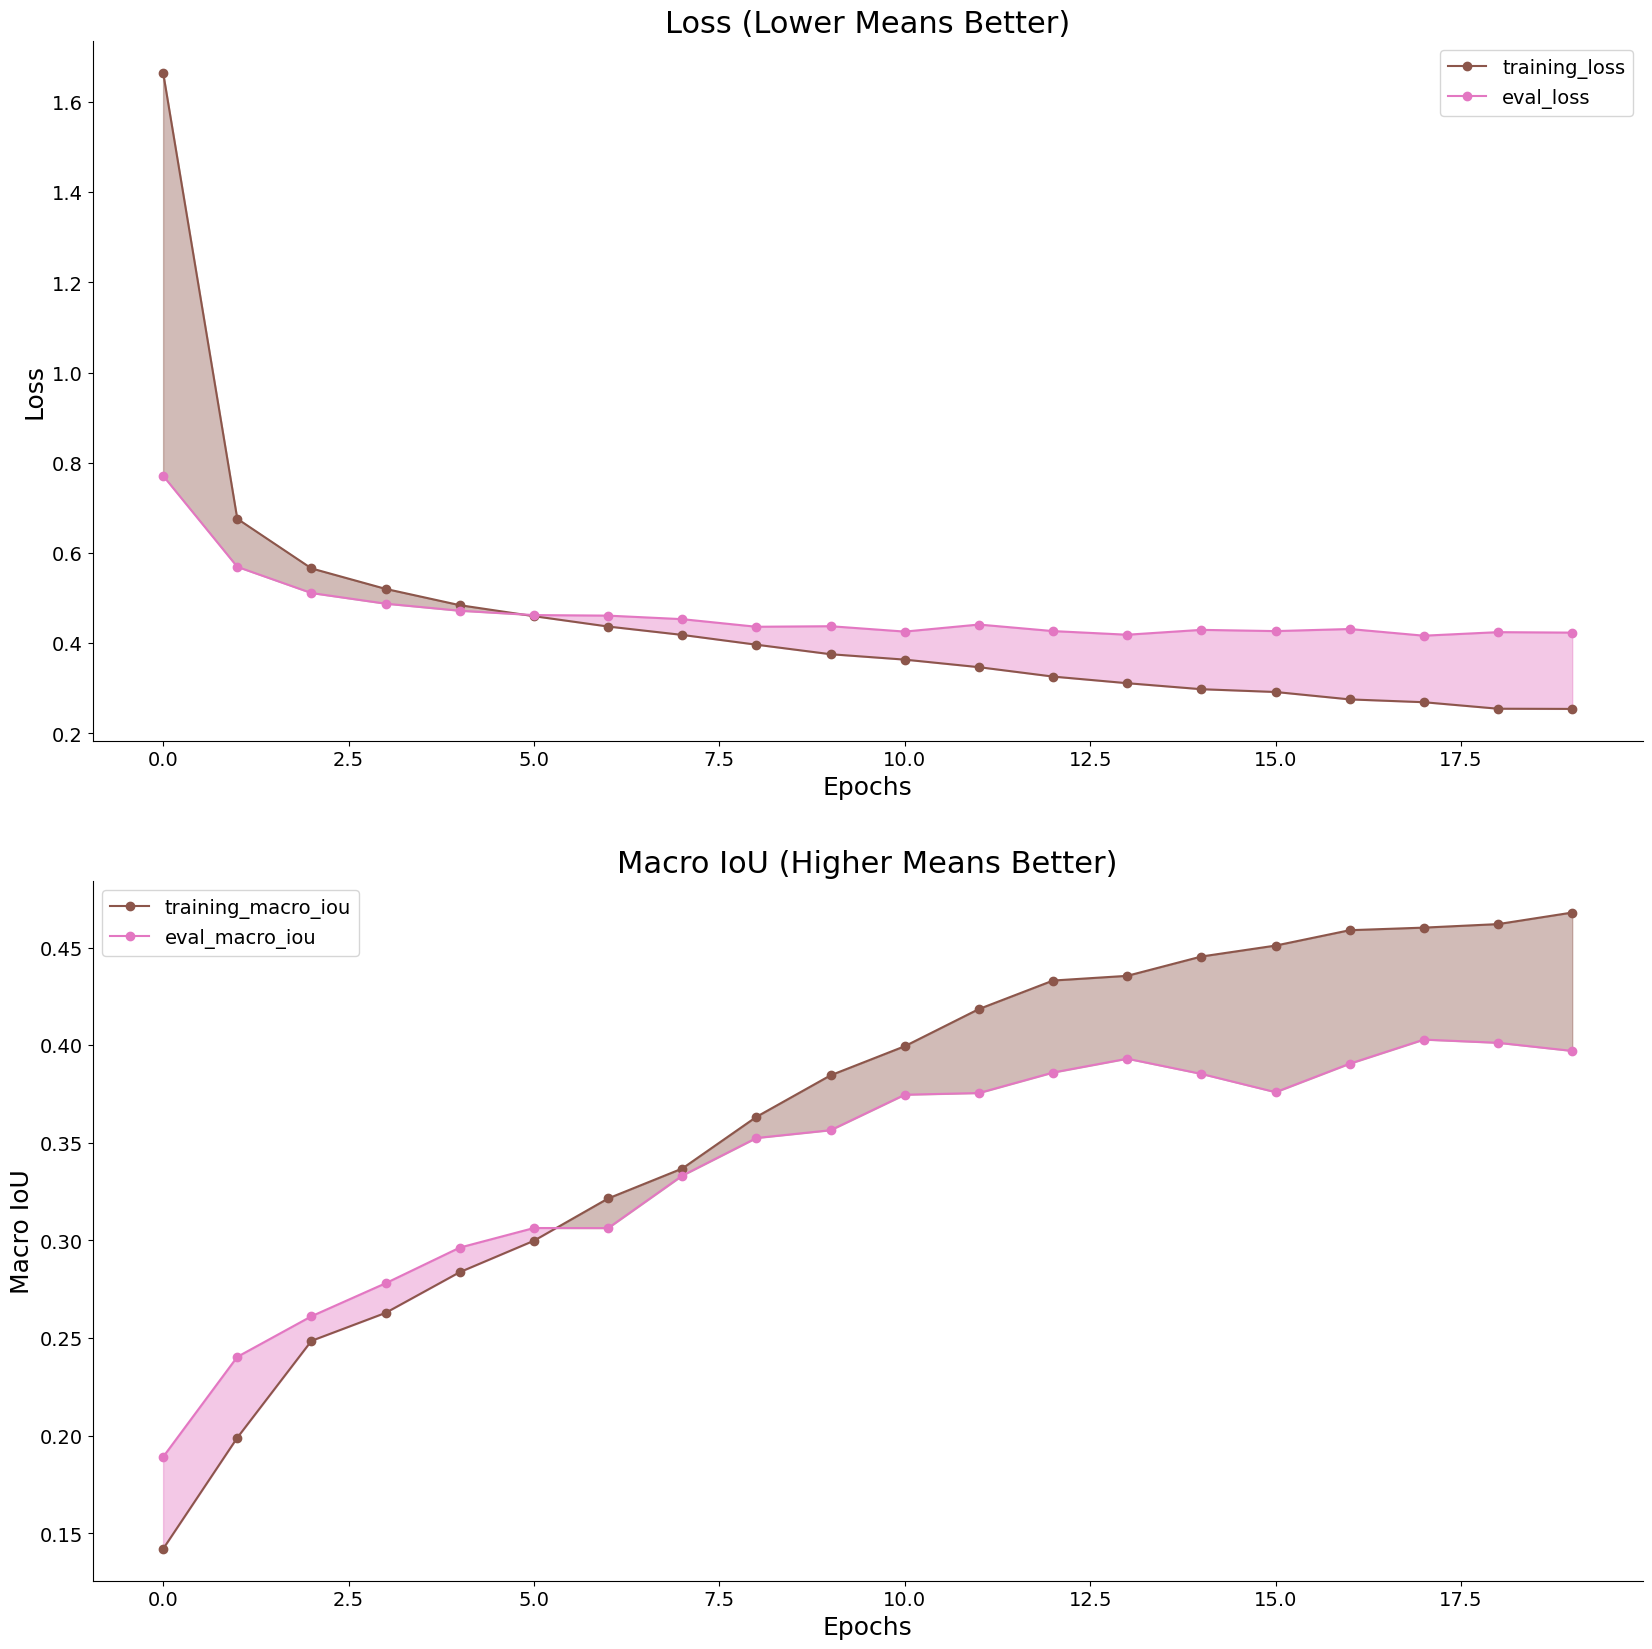

In [14]:
# Print current Torch package versions
print('Package versions:')
print('*'*26)
print(f'torch \t\t - {torch.__version__}')
print(f'torchvision \t - {torchvision.__version__}')

train_df, val_df, test_df = load_dataset_from_files()

train_transforms = A.Compose([
    A.Resize(height=Configuration.IMAGE_HEIGHT, width=Configuration.IMAGE_WIDTH),
    A.RandomBrightnessContrast(p=0.2),
    A.HorizontalFlip(p=0.5),
    # The mask is now a 2-D class-index map, so ``ToTensorV2`` needs no
    # ``transpose_mask``: it leaves the (H, W) mask as-is and only converts
    # the image to (C, H, W).
    ToTensorV2(),
])

inference_transforms = A.Compose([
    A.Resize(height=Configuration.IMAGE_HEIGHT, width=Configuration.IMAGE_WIDTH),
    ToTensorV2(),
])
train_ds = BDDSegmentationDataset(train_df, transform=train_transforms)
val_ds = BDDSegmentationDataset(val_df, transform=inference_transforms)

# Calculate class weights only if the NPY file does not exist, and reuse if
# that file exists. This bypasses the slow PNG mask decoding pass on repeated runs.
if os.path.exists(Path.CLASS_WEIGHTS_PATH):
    print(f"Reusing precomputed class weights from '{Path.CLASS_WEIGHTS_PATH}'...")
    train_sample_weights = np.load(Path.CLASS_WEIGHTS_PATH)
else:
    print(
        f"Class weights file '{Path.CLASS_WEIGHTS_PATH}' not found. "
        "Calculating class weights from training masks..."
    )
    train_sample_weights = calculate_and_save_class_weights(
        df=train_df,
        output_path=Path.CLASS_WEIGHTS_PATH,
        num_classes=Configuration.NUM_CLASSES,
        boundary_class_ids=BOUNDARY_CLASS_IDS,
    )

# Build sampler drawing minority-class frames more frequently with replacement
train_sampler = WeightedRandomSampler(
    weights=train_sample_weights.tolist(),
    num_samples=len(train_ds),
    replacement=True,
)

# ``shuffle`` and ``sampler`` are mutually exclusive in ``DataLoader``; the
# sampler already provides the weighted random ordering.
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=Configuration.BATCH_SIZE,
    sampler=train_sampler,
)
val_loader = DataLoader(
        dataset=val_ds,
        batch_size=Configuration.BATCH_SIZE,
        shuffle=Configuration.APPLY_SHUFFLE
    )

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=Configuration.CHANNELS,
    classes=Configuration.NUM_CLASSES
)

print(
    summary(
            model=model,
            input_size=(Configuration.BATCH_SIZE, Configuration.CHANNELS, Configuration.IMAGE_HEIGHT, Configuration.IMAGE_WIDTH),
            col_names=["output_size", "num_params", "trainable"],
            col_width=30,
            row_settings=["var_names"],
            depth=5
        )
)

# Instantiate the compound loss module combining Dice and Focal losses.
# An nn.Module subclass is used so it satisfies the jaxtyped/beartype constraint
# (loss_fn: nn.Module) and automatically handles one-hot to class-index target mapping.
loss_fn = CompoundLoss(
    dice_weight=0.5,
    focal_weight=1.0,
    ignore_index=19,
)

# Define optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Configuration.LR
)

# Define Scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    patience=Configuration.PATIENCE
)

print('Training U-Net Model')
print(f'Train on {len(train_df)} samples, validate on {len(val_df)} samples.')
print('----------------------------------')

# Generate training session config
session_config = {
    'model'               : model,
    'train_dataloader'    : train_loader,
    'eval_dataloader'     : val_loader,
    'optimizer'           : optimizer,
    'scheduler'           : scheduler,
    'loss_fn'             : loss_fn,
    'epochs'              : Configuration.EPOCHS,
    'train_device'        : Configuration.DEVICE,
    'eval_device'         : Configuration.DEVICE,
}

# Execute Training Session
unet_session_history = train(**session_config)

# Create Model directory
model_name = 'teacher'
model_path = './model/'
os.mkdir(model_path)

# Save Model
torch.save(model, model_path + model_name + '.pt')

# Convert U-Net history dict to DataFrame
unet_session_history_df = pd.DataFrame(unet_session_history)
print(unet_session_history_df)

# Plot U-Net Session Training History
plot_training_curves(
    unet_session_history,
    fig_size=(20, 20)
)


# Export a grid of test samples (image / image+true mask /
# image+predicted mask) so the model output can be inspected visually.
visualize_predictions(
    model,
    test_df,
    torch.device(Configuration.DEVICE)
)